# Proyek Klasifikasi Gambar: Javanese Handwriting Classification


## Import Library

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from skimage.feature import hog
from skimage import exposure
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

## Load Dataset dari Kaggle

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download('vzrenggamani/hanacaraka')
print('Dataset path:', path)

DATA_DIR = path
for root, dirs, files in os.walk(path):
    subdirs_with_images = [
        d for d in dirs
        if any(f.lower().endswith(('.png','.jpg','.jpeg'))
               for f in os.listdir(os.path.join(root, d)))
    ]
    if len(subdirs_with_images) >= 5:
        DATA_DIR = root
        break

CLASSES   = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
N_CLASSES = len(CLASSES)
print(f'Folder dataset : {DATA_DIR}')
print(f'Jumlah kelas   : {N_CLASSES}')
print(f'Daftar kelas   : {CLASSES}')

100%|██████████| 9.20M/9.20M [00:00<00:00, 75.5MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37
Folder dataset : /root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37
Jumlah kelas   : 20
Daftar kelas   : ['ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya']







## EDA Eksplorasi Data

In [3]:
all_paths, all_labels = [], []
class_counts = {}

for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_dir)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[cls] = len(files)
    for f in files:
        all_paths.append(os.path.join(cls_dir, f))
        all_labels.append(cls)

print(f'Total gambar   : {len(all_paths)}')
print(f'Per kelas      : min={min(class_counts.values())} | max={max(class_counts.values())} | rata={np.mean(list(class_counts.values())):.0f}')

Total gambar   : 1579
Per kelas      : min=78 | max=79 | rata=79


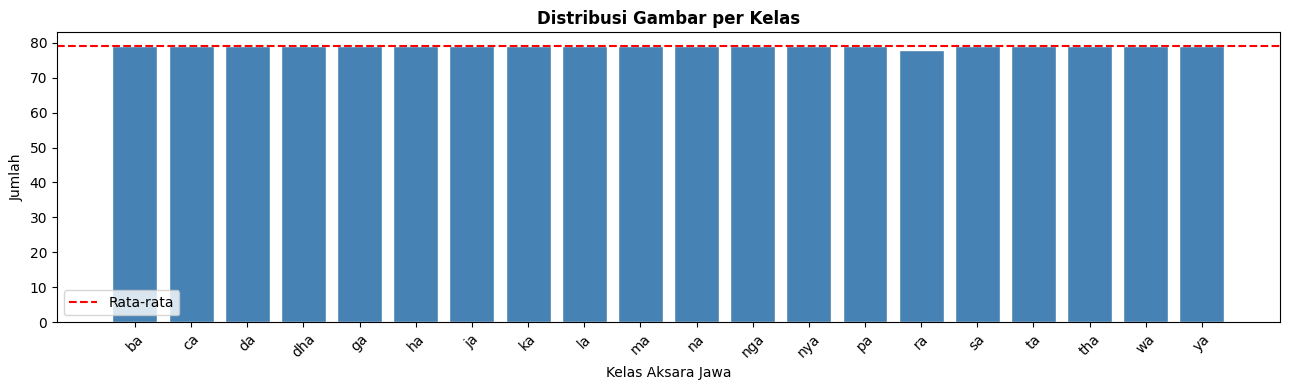

In [4]:
# Distribusi kelas
plt.figure(figsize=(13, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='white')
plt.axhline(np.mean(list(class_counts.values())), color='red', linestyle='--', label='Rata-rata')
plt.title('Distribusi Gambar per Kelas', fontweight='bold')
plt.xlabel('Kelas Aksara Jawa'); plt.ylabel('Jumlah')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

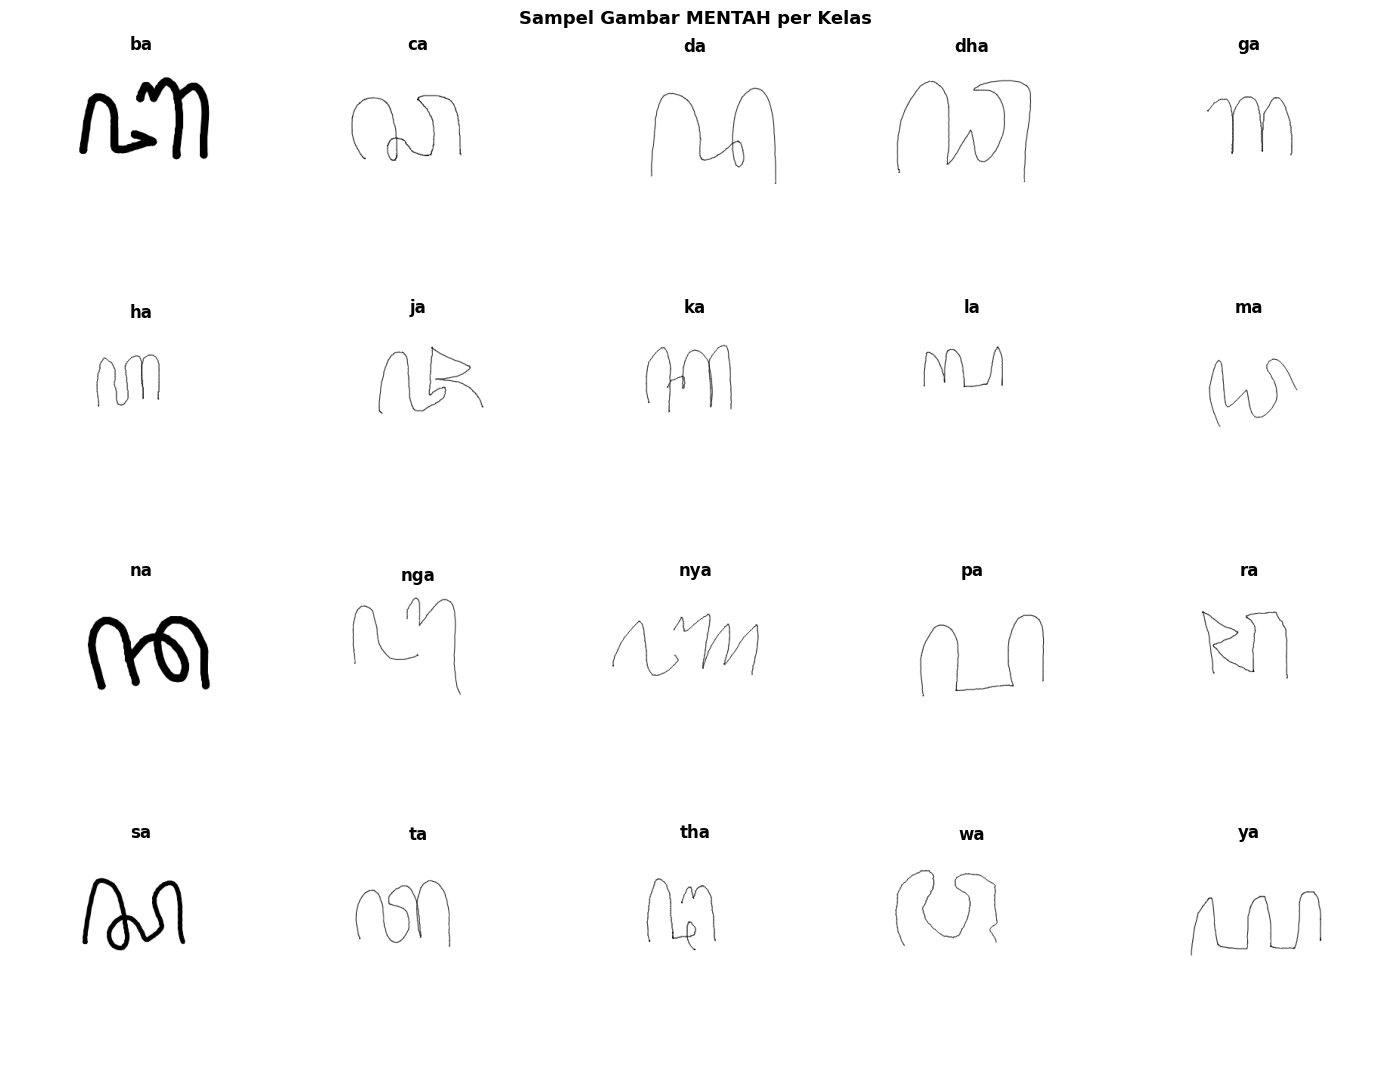

In [5]:
# Sampel gambar mentah tiap kelas
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Sampel Gambar MENTAH per Kelas', fontsize=13, fontweight='bold')
for i, cls in enumerate(CLASSES):
    ax = axes[i//5][i%5]
    cls_dir = os.path.join(DATA_DIR, cls)
    f = random.choice([x for x in os.listdir(cls_dir) if x.endswith('.png')])
    ax.imshow(Image.open(os.path.join(cls_dir, f)).convert('L'), cmap='gray')
    ax.set_title(cls, fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.show()

## Preprocessing

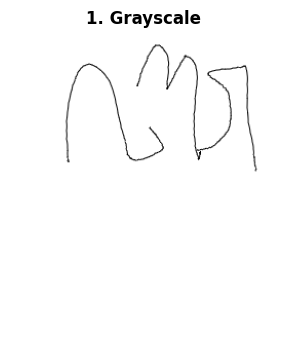

In [6]:
example_image_path = all_paths[0]
img_step_1 = np.array(Image.open(example_image_path).convert('L'))
plt.figure(figsize=(4, 4))
plt.imshow(img_step_1, cmap='gray')
plt.title('1. Grayscale', fontweight='bold')
plt.axis('off')
plt.show()

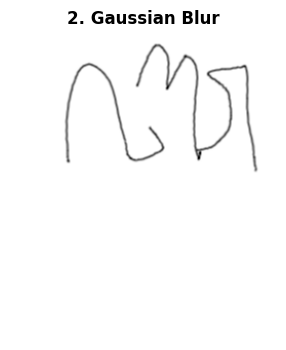

In [7]:
# 2. Gaussian Blur
img_step_2 = cv2.GaussianBlur(img_step_1, (3, 3), 0)
plt.figure(figsize=(4, 4))
plt.imshow(img_step_2, cmap='gray')
plt.title('2. Gaussian Blur', fontweight='bold')
plt.axis('off')
plt.show()

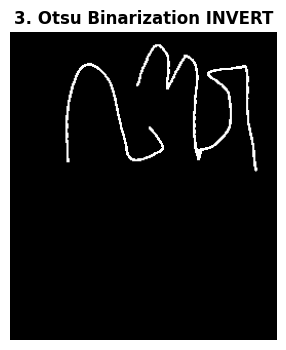

In [8]:
# 3. Otsu Binarization INVERT
img_step_2_8bit = cv2.convertScaleAbs(img_step_2)
_, img_step_3 = cv2.threshold(img_step_2_8bit, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.figure(figsize=(4, 4))
plt.imshow(img_step_3, cmap='gray')
plt.title('3. Otsu Binarization INVERT', fontweight='bold')
plt.axis('off')
plt.show()

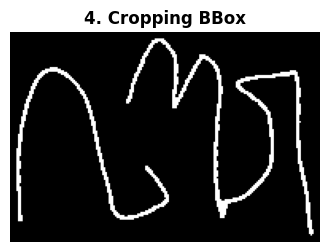

In [9]:
# 4. Cropping BBox
coords = cv2.findNonZero(img_step_3)
if coords is not None:
    x, y, w, h = cv2.boundingRect(coords)
    margin = 4
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(img_step_3.shape[1], x + w + margin)
    y2 = min(img_step_3.shape[0], y + h + margin)
    img_step_4 = img_step_3[y1:y2, x1:x2]
else:
    img_step_4 = img_step_3
plt.figure(figsize=(4, 4))
plt.imshow(img_step_4, cmap='gray')
plt.title('4. Cropping BBox', fontweight='bold')
plt.axis('off')
plt.show()

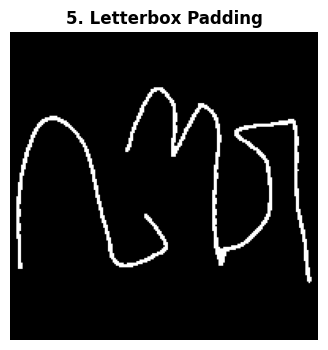

In [10]:
# 5. Letterbox Padding
h, w = img_step_4.shape
size = max(h, w)
square = np.zeros((size, size), dtype=np.uint8)
y_offset = (size - h) // 2
x_offset = (size - w) // 2
square[y_offset:y_offset + h,
       x_offset:x_offset + w] = img_step_4
img_step_5 = square
plt.figure(figsize=(4, 4))
plt.imshow(img_step_5, cmap='gray')
plt.title('5. Letterbox Padding', fontweight='bold')
plt.axis('off')
plt.show()

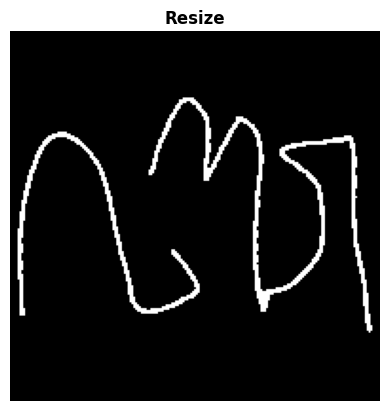

In [11]:
# Resize
resized = cv2.resize(
    square,
    (size, size),
    interpolation=cv2.INTER_AREA
)
plt.imshow(resized, cmap='gray')
plt.axis('off')
plt.title('Resize', fontweight='bold')
plt.show()

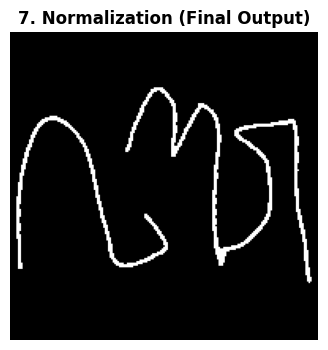

Shape gambar setelah preprocessing: (195, 195)
Min pixel: 0.000
Max pixel: 1.000


In [12]:
# 7. Normalize
img_step_7 = resized.astype(np.float32) / 255.0
plt.figure(figsize=(4, 4))
plt.imshow(img_step_7, cmap='gray')
plt.title('7. Normalization (Final Output)', fontweight='bold')
plt.axis('off')
plt.show()

print(f'Shape gambar setelah preprocessing: {img_step_7.shape}')
print(f'Min pixel: {img_step_7.min():.3f}')
print(f'Max pixel: {img_step_7.max():.3f}')

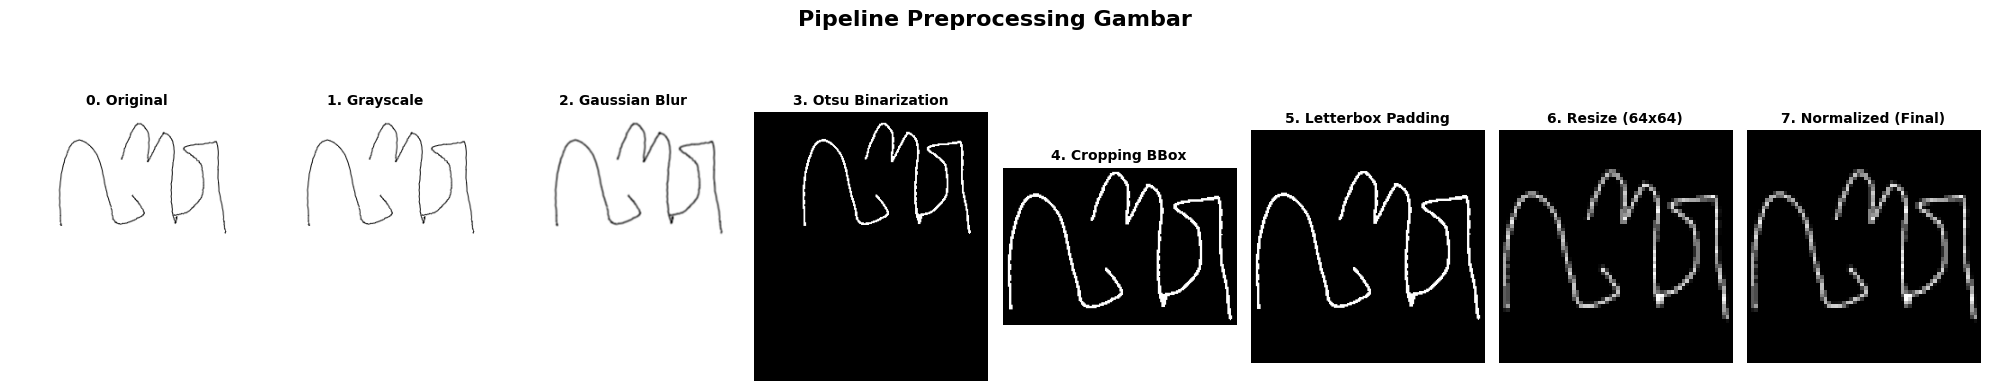

In [13]:
example_image_path = all_paths[0]

# Original Image (untuk perbandingan)
img_original = Image.open(example_image_path)

# Define IMG_SIZE for consistent preprocessing demonstration
IMG_SIZE = 64

# 1. Grayscale
img_step_1 = np.array(img_original.convert('L'))

# 2. Gaussian Blur
img_step_2 = cv2.GaussianBlur(img_step_1, (3, 3), 0)

# 3. Otsu Binarization INVERT
img_step_2_8bit = cv2.convertScaleAbs(img_step_2)
_, img_step_3 = cv2.threshold(img_step_2_8bit, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 4. Cropping BBox
coords = cv2.findNonZero(img_step_3)
if coords is not None:
    x, y, w, h = cv2.boundingRect(coords)
    margin = 4
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(img_step_3.shape[1], x + w + margin)
    y2 = min(img_step_3.shape[0], y + h + margin)
    img_step_4 = img_step_3[y1:y2, x1:x2]
else:
    img_step_4 = img_step_3

# 5. Letterbox Padding
h_cropped, w_cropped = img_step_4.shape
size_padded = max(h_cropped, w_cropped)
square_padded = np.zeros((size_padded, size_padded), dtype=np.uint8)
y_offset_padded = (size_padded - h_cropped) // 2
x_offset_padded = (size_padded - w_cropped) // 2
square_padded[y_offset_padded:y_offset_padded + h_cropped,
              x_offset_padded:x_offset_padded + w_cropped] = img_step_4
img_step_5 = square_padded

# 6. Resize (using IMG_SIZE from the notebook's global variable)
img_step_6 = cv2.resize(
    img_step_5,
    (IMG_SIZE, IMG_SIZE),
    interpolation=cv2.INTER_AREA
)

# 7. Normalize
img_step_7 = img_step_6.astype(np.float32) / 255.0

# Create a list of images and their titles for plotting
images = [
    (img_original, '0. Original'),
    (img_step_1, '1. Grayscale'),
    (img_step_2, '2. Gaussian Blur'),
    (img_step_3, '3. Otsu Binarization'),
    (img_step_4, '4. Cropping BBox'),
    (img_step_5, '5. Letterbox Padding'),
    (img_step_6, f'6. Resize ({IMG_SIZE}x{IMG_SIZE})'),
    (img_step_7, '7. Normalized (Final)')
]

# Plot all images in a single figure
fig, axes = plt.subplots(1, len(images), figsize=(20, 4))
fig.suptitle('Pipeline Preprocessing Gambar', fontsize=16, fontweight='bold', y=1.05)

for i, (image, title) in enumerate(images):
    ax = axes[i]
    # Handle PIL Image specifically for the original one before converting to numpy
    if isinstance(image, Image.Image):
        ax.imshow(np.array(image.convert('L')), cmap='gray')
    else:
        ax.imshow(image, cmap='gray')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Loading 1579 gambar dengan size=64...
  Skip: /root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/dha/4696038101413220221_base64_32.png — cannot identify image file '/root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/dha/4696038101413220221_base64_32.png'
  Skip: /root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/dha/4697111846216686148_base64_32.png — cannot identify image file '/root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/dha/4697111846216686148_base64_32.png'
  Skip: /root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/ga/4696394596413810473_base64_43.png — cannot identify image file '/root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/ga/4696394596413810473_base64_43.png'
  Skip: /root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/ha/4694803355817399930_base64_5.png — cannot identify image file '/root/.cache/kagglehub/datasets/vzrenggamani/hanacaraka/versions/37/h

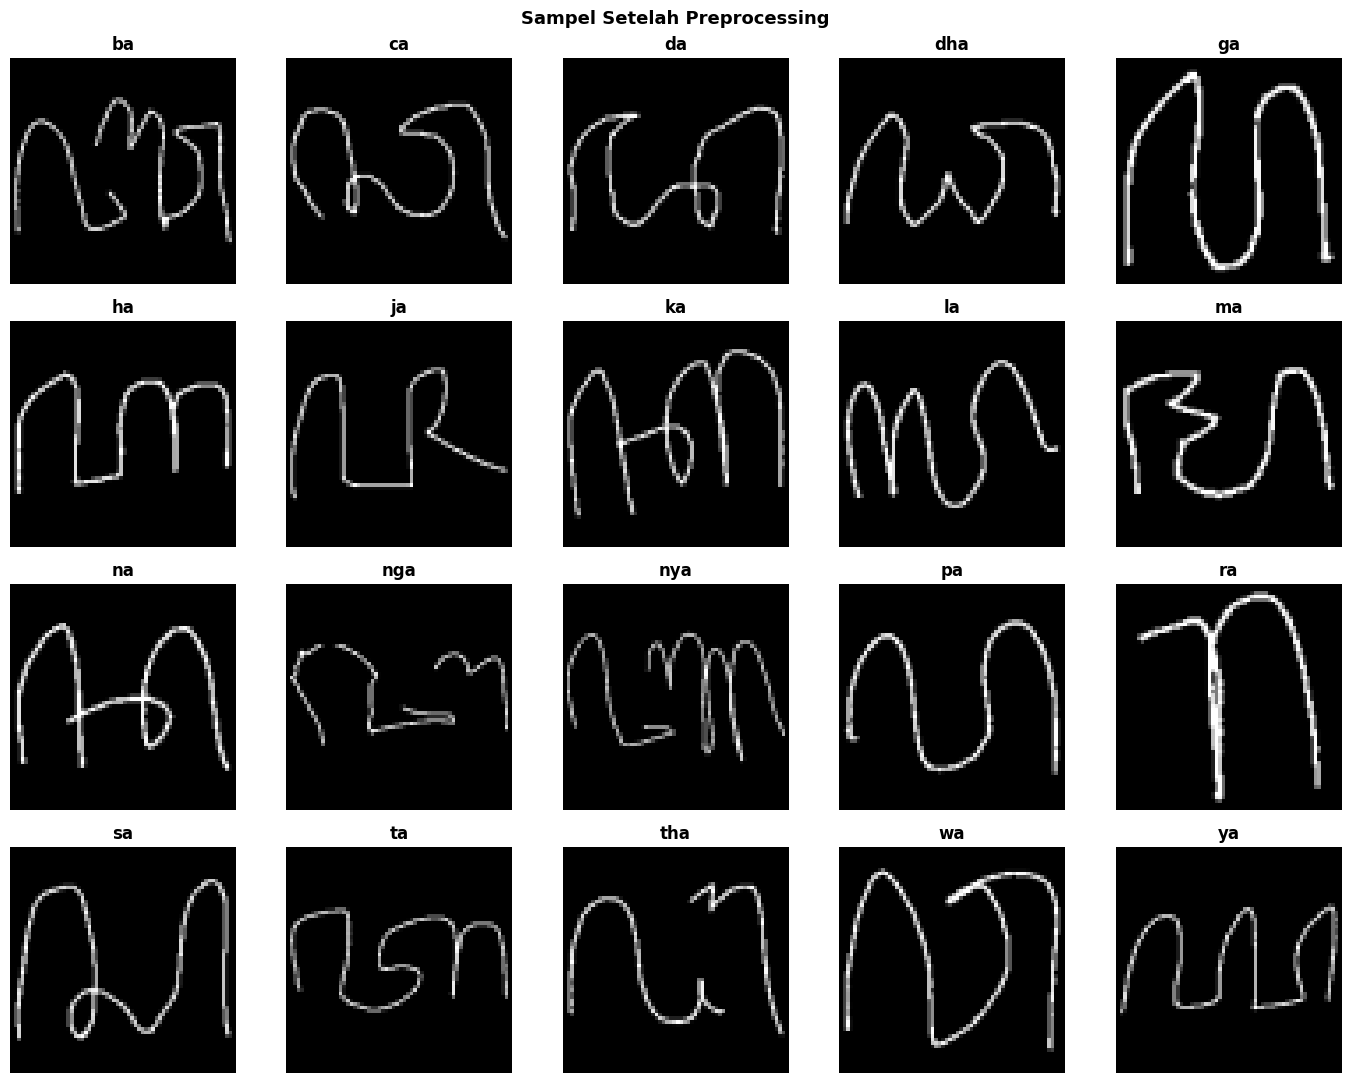

In [14]:
# ── Load semua gambar ─────────────────────────────────────────

# Define the preprocess function
def preprocess(image_path, target_size):
    # 1. Open image and convert to grayscale
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)

    # 2. Gaussian Blur
    img_step_2 = cv2.GaussianBlur(img_np, (3, 3), 0)

    # 3. Otsu Binarization INVERT
    img_step_2_8bit = cv2.convertScaleAbs(img_step_2)
    _, img_step_3 = cv2.threshold(img_step_2_8bit, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Cropping BBox
    coords = cv2.findNonZero(img_step_3)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        margin = 4
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(img_step_3.shape[1], x + w + margin)
        y2 = min(img_step_3.shape[0], y + h + margin)
        img_step_4 = img_step_3[y1:y2, x1:x2]
    else:
        img_step_4 = img_step_3

    # 5. Letterbox Padding
    h_cropped, w_cropped = img_step_4.shape
    size_padded = max(h_cropped, w_cropped)
    square_padded = np.zeros((size_padded, size_padded), dtype=np.uint8)
    y_offset_padded = (size_padded - h_cropped) // 2
    x_offset_padded = (size_padded - w_cropped) // 2
    square_padded[y_offset_padded:y_offset_padded + h_cropped,
                  x_offset_padded:x_offset_padded + w_cropped] = img_step_4

    # 6. Resize
    resized_img = cv2.resize(
        square_padded,
        (target_size, target_size),
        interpolation=cv2.INTER_AREA
    )

    # 7. Normalize
    normalized_img = resized_img.astype(np.float32) / 255.0
    return normalized_img


IMG_SIZE = 64
le = LabelEncoder()
le.fit(CLASSES)

print(f'Loading {len(all_paths)} gambar dengan size={IMG_SIZE}...')
X_all, y_all = [], []

for path, label in zip(all_paths, all_labels):
    try:
        X_all.append(preprocess(path, IMG_SIZE))
        y_all.append(label)
    except Exception as e:
        print(f'  Skip: {path} — {e}')

X_all = np.array(X_all, dtype=np.float32)  # (N, 96, 96)
y_all = np.array(le.transform(y_all))       # (N,) integer 0-19

print(f'X shape : {X_all.shape}')
print(f'X mean  : {X_all.mean():.3f} | X std: {X_all.std():.3f}')
print(f'Kelas   : {len(np.unique(y_all))} kelas')

# Sampel hasil preprocessing
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Sampel Setelah Preprocessing', fontsize=13, fontweight='bold')
for i, cls in enumerate(CLASSES):
    ax = axes[i//5][i%5]
    mask = (y_all == i)
    # Ensure there's at least one image for the class before trying to display
    if np.any(mask):
        ax.imshow(X_all[mask][0], cmap='gray')
    else:
        ax.text(0.5, 0.5, 'No Image', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_title(cls, fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.show()

In [15]:
#  Stratified Split 70 / 15 / 15
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 1093
Val   : 234
Test  : 235


## Data Augmentation

In [16]:
# SVM tidak punya augmentasi otomatis seperti Keras
def augment_for_svm(X, y):
    aug_X, aug_y = list(X), list(y)
    for img, lbl in zip(X, y):
        img8 = (img * 255).astype(np.uint8)
        h, w = img.shape
        for angle in [-12, 12]:  # rotasi
            M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
            r = cv2.warpAffine(img8, M, (w,h), borderValue=0).astype(np.float32)/255.0
            aug_X.append(r); aug_y.append(lbl)
        for tx in [-5, 5]:       # geser horizontal
            M = np.float32([[1,0,tx],[0,1,0]])
            s = cv2.warpAffine(img8, M, (w,h), borderValue=0).astype(np.float32)/255.0
            aug_X.append(s); aug_y.append(lbl)
    return np.array(aug_X), np.array(aug_y)

print('Augmentasi data training SVM...')
X_aug, y_aug = augment_for_svm(X_train, y_train)
print(f'Train: {len(X_train)} → {len(X_aug)} (5x lipat)')

Augmentasi data training SVM...
Train: 1093 → 5465 (5x lipat)


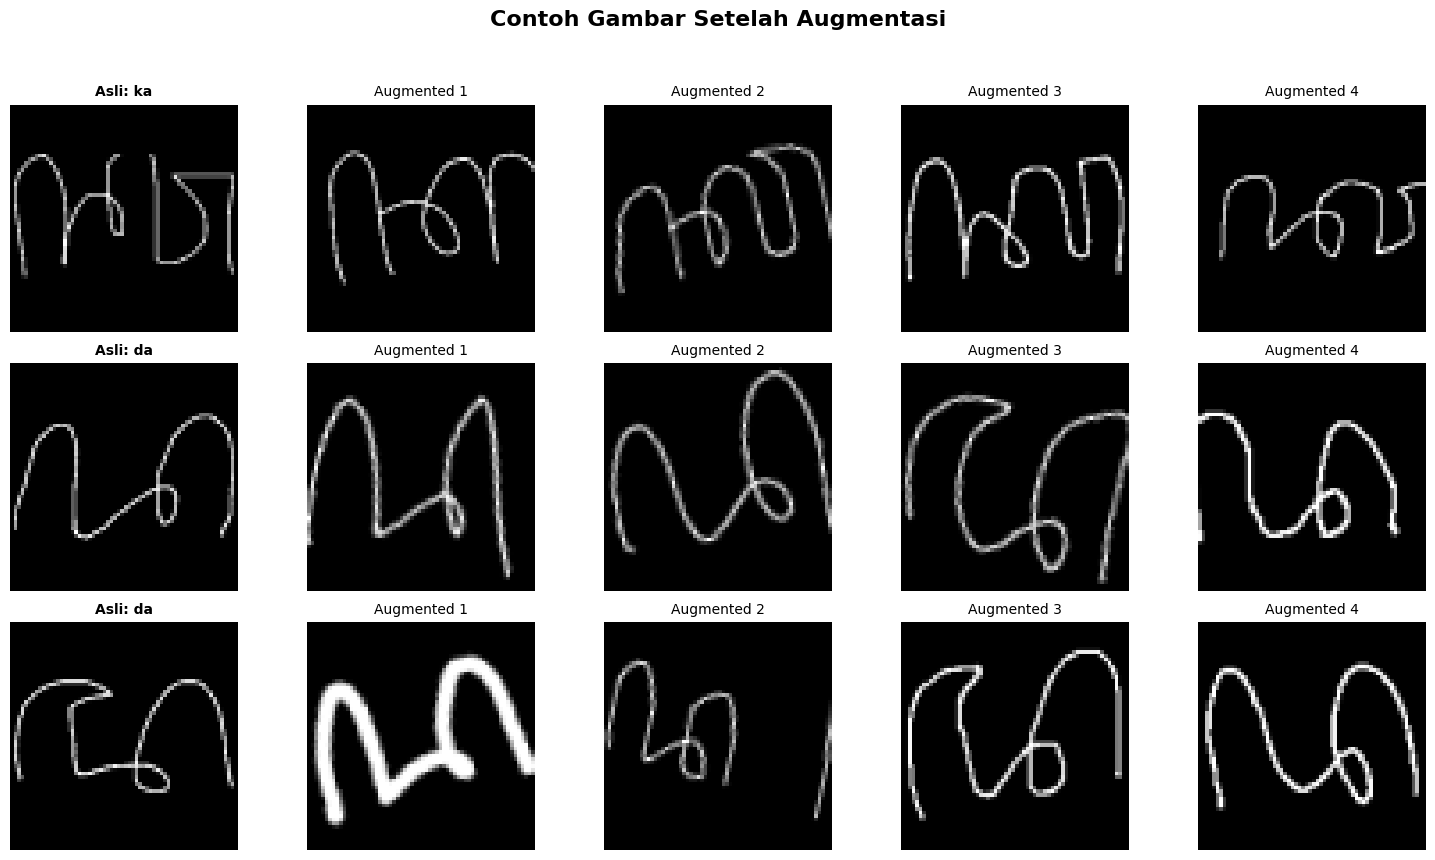

In [17]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Contoh Gambar Setelah Augmentasi', fontsize=16, fontweight='bold')

# Pilih beberapa indeks gambar asli untuk menampilkan variasinya
sample_indices = np.random.choice(len(X_train), 3, replace=False)

for i, original_idx in enumerate(sample_indices):
    original_image = X_train[original_idx]
    original_label = y_train[original_idx]

    # Tampilkan gambar asli
    ax = axes[i, 0]
    ax.imshow(original_image, cmap='gray')
    ax.set_title(f'Asli: {le.classes_[original_label]}', fontsize=10, fontweight='bold')
    ax.axis('off')


    aug_indices_for_label = np.where(y_aug == original_label)[0]
    if len(aug_indices_for_label) > 4: # Pastikan ada cukup augmented images untuk ditampilkan
        display_aug_indices = np.random.choice(aug_indices_for_label, 4, replace=False)
    else:
        display_aug_indices = aug_indices_for_label # Jika kurang dari 4, tampilkan semua yang ada

    for j, aug_idx in enumerate(display_aug_indices):
        if j < 4: # Tampilkan maksimal 4 augmented samples
            ax = axes[i, j + 1]
            ax.imshow(X_aug[aug_idx], cmap='gray')
            ax.set_title(f'Augmented {j+1}', fontsize=10)
            ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## 5. Model 1 — SVM + HOG

### 5.1 Ekstraksi Fitur HOG

Setelah augmentasi data, kita akan mengekstrak fitur Histogram of Oriented Gradients (HOG) dari setiap gambar. Fitur HOG ini akan digunakan sebagai input untuk model SVM.

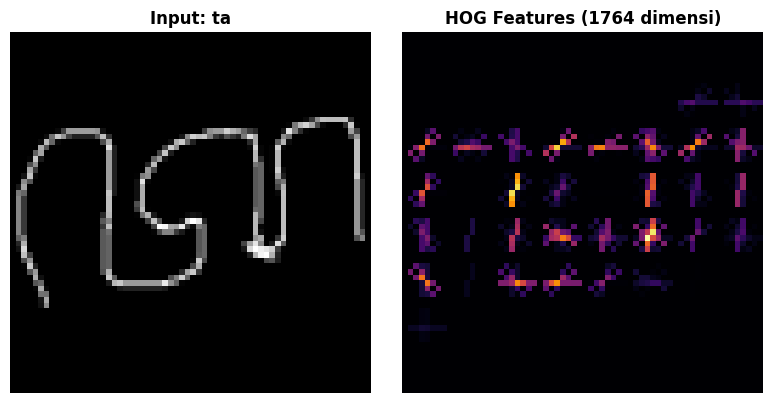

Ekstraksi HOG...
HOG dim: 1764 fitur


In [18]:
# ── Ekstraksi HOG ─────────────────────────────────────────────
def extract_hog(images):
    return np.array([
        hog(
            img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )
        for img in images
    ], dtype=np.float32)

# Visualisasi HOG
hog_feat, hog_vis = hog(X_train[0], orientations=9,
                         pixels_per_cell=(8,8), cells_per_block=(2,2),
                         block_norm='L2-Hys', visualize=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(X_train[0], cmap='gray'); ax1.set_title(f'Input: {le.classes_[y_train[0]]}', fontweight='bold'); ax1.axis('off')
ax2.imshow(exposure.rescale_intensity(hog_vis, in_range=(0,10)), cmap='inferno')
ax2.set_title(f'HOG Features ({len(hog_feat)} dimensi)', fontweight='bold'); ax2.axis('off')
plt.tight_layout(); plt.show()

print('Ekstraksi HOG...')
H_train = extract_hog(X_aug)
H_val   = extract_hog(X_val)
H_test  = extract_hog(X_test)
print(f'HOG dim: {H_train.shape[1]} fitur')

### 5.2 Training Model SVM

In [19]:
# ── Training SVM ─────────────────────────────────────────────
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, gamma='scale',
                decision_function_shape='ovo',
                class_weight='balanced',
                random_state=SEED))
])

print('Training SVM...')
svm_pipe.fit(H_train, y_aug)
print('Selesai!')

acc_tr  = accuracy_score(y_aug, svm_pipe.predict(H_train))
acc_val = accuracy_score(y_val, svm_pipe.predict(H_val))
acc_test = accuracy_score(y_test, svm_pipe.predict(H_test))
print(f'\nTrain acc : {acc_tr*100:.2f}%')
print(f'Val acc   : {acc_val*100:.2f}%')
print(f'Test acc  : {acc_test*100:.2f}')
print(f'Gap       : {(acc_tr-acc_val)*100:.2f}%')

Training SVM...
Selesai!

Train acc : 98.96%
Val acc   : 83.33%
Test acc  : 86.81
Gap       : 15.62%


In [20]:
y_pred_svm = svm_pipe.predict(H_test)

print("Classification Report SVM:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=le.classes_,
    zero_division=0
))

Classification Report SVM:
              precision    recall  f1-score   support

          ba       0.91      0.83      0.87        12
          ca       1.00      0.92      0.96        12
          da       0.92      0.92      0.92        12
         dha       1.00      0.82      0.90        11
          ga       0.64      0.58      0.61        12
          ha       0.73      0.92      0.81        12
          ja       1.00      0.92      0.96        12
          ka       0.85      0.92      0.88        12
          la       1.00      0.75      0.86        12
          ma       1.00      1.00      1.00        12
          na       0.86      1.00      0.92        12
         nga       0.67      0.83      0.74        12
         nya       0.85      0.92      0.88        12
          pa       0.83      0.91      0.87        11
          ra       0.91      0.91      0.91        11
          sa       0.92      1.00      0.96        12
          ta       0.90      0.82      0.86        11


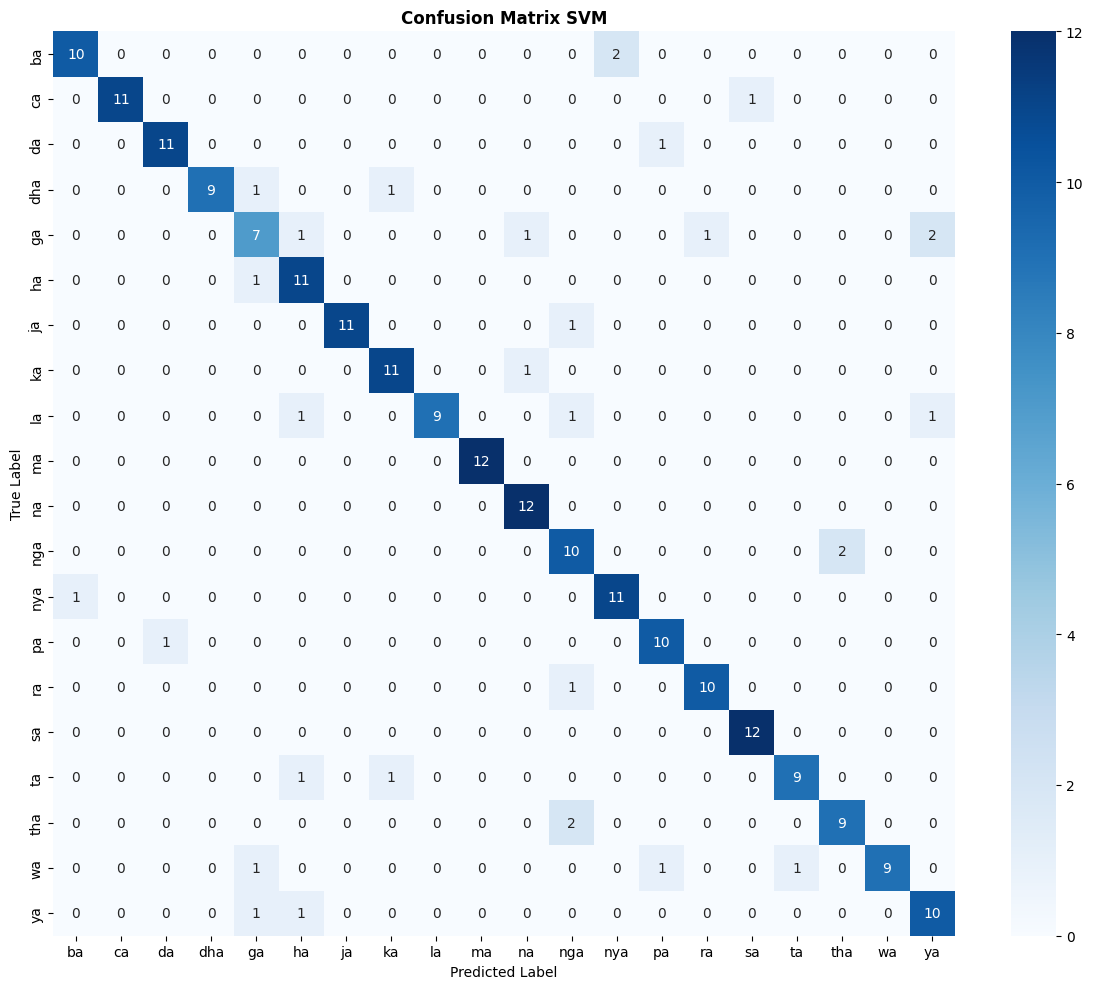

In [22]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix SVM', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# CNN

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [24]:
# reshape

X_train_cnn = X_aug[..., np.newaxis]     # dari (N, 64, 64) menjadi (N, 64, 64, 1)
X_val_cnn   = X_val[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

y_train_cnn = y_aug
y_val_cnn   = y_val
y_test_cnn  = y_test

print("Shape data CNN:")
print("X_train_cnn:", X_train_cnn.shape)
print("X_val_cnn  :", X_val_cnn.shape)
print("X_test_cnn :", X_test_cnn.shape)
print("Jumlah kelas:", N_CLASSES)

Shape data CNN:
X_train_cnn: (5465, 64, 64, 1)
X_val_cnn  : (234, 64, 64, 1)
X_test_cnn : (235, 64, 64, 1)
Jumlah kelas: 20


In [25]:
# Arsitektur CNN
cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    # Blok Convolution 1
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Blok Convolution 2
    layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Blok Convolution 3
    layers.Conv2D(
        128, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layer
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(N_CLASSES, activation='softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,852 (4.37 MB)

 Trainable params: 1,144,404 (4.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
# Compile model CNN

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:

# Callback

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [28]:
# Training CNN
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.0869 - loss: 3.1669 - val_accuracy: 0.0513 - val_loss: 15.9694 - learning_rate: 0.0010
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1231 - loss: 2.9000 - val_accuracy: 0.1410 - val_loss: 6.1383 - learning_rate: 0.0010
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1513 - loss: 2.7713 - val_accuracy: 0.2735 - val_loss: 2.4553 - learning_rate: 0.0010
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1771 - loss: 2.6550 - val_accuracy: 0.2906 - val_loss: 2.2547 - learning_rate: 0.0010
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2079 - loss: 2.5061 - val_accuracy: 0.3932 - val_loss: 1.9737 - learning_rate: 0.0010
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2465 - loss: 2.3752 - val_accuracy: 0.4145 - val_loss: 1.9369 - learning_rate: 0.0010
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2822 - loss: 2.2320

In [29]:
# Evaluasi CNN

train_loss_cnn, train_acc_cnn = cnn_model.evaluate(X_train_cnn, y_train_cnn, verbose=0)
val_loss_cnn, val_acc_cnn     = cnn_model.evaluate(X_val_cnn, y_val_cnn, verbose=0)
test_loss_cnn, test_acc_cnn   = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)

print("HASIL EVALUASI CNN")
print(f"Train Accuracy      : {train_acc_cnn * 100:.2f}%")
print(f"Validation Accuracy : {val_acc_cnn * 100:.2f}%")
print(f"Test Accuracy       : {test_acc_cnn * 100:.2f}%")
print(f"Gap Train-Val       : {(train_acc_cnn - val_acc_cnn) * 100:.2f}%")

HASIL EVALUASI CNN
Train Accuracy      : 96.69%
Validation Accuracy : 90.60%
Test Accuracy       : 90.21%
Gap Train-Val       : 6.09%


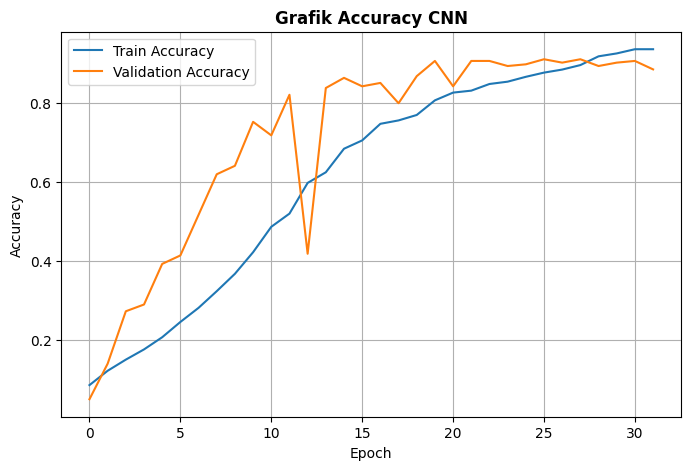

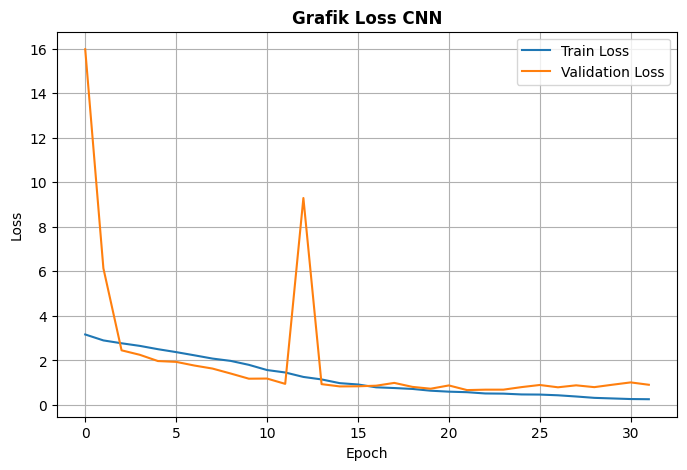

In [30]:
# Grafik Accuracy CNN

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Accuracy CNN', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Grafik Loss CNN
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss CNN', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Classification Report CNN

y_pred_prob_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_prob_cnn, axis=1)

print("Classification Report CNN:")
print(classification_report(
    y_test_cnn,
    y_pred_cnn,
    target_names=le.classes_
))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
Classification Report CNN:
              precision    recall  f1-score   support

          ba       0.86      1.00      0.92        12
          ca       1.00      0.92      0.96        12
          da       1.00      1.00      1.00        12
         dha       1.00      0.82      0.90        11
          ga       0.69      0.75      0.72        12
          ha       0.75      1.00      0.86        12
          ja       1.00      1.00      1.00        12
          ka       0.92      1.00      0.96        12
          la       1.00      0.75      0.86        12
          ma       1.00      1.00      1.00        12
          na       1.00      1.00      1.00        12
         nga       0.73      0.92      0.81        12
         nya       0.92      0.92      0.92        12
          pa       0.91      0.91      0.91        11
          ra       1.00      0.73      0.84        11
          sa       0.92      1.00      0.96        12
          ta    

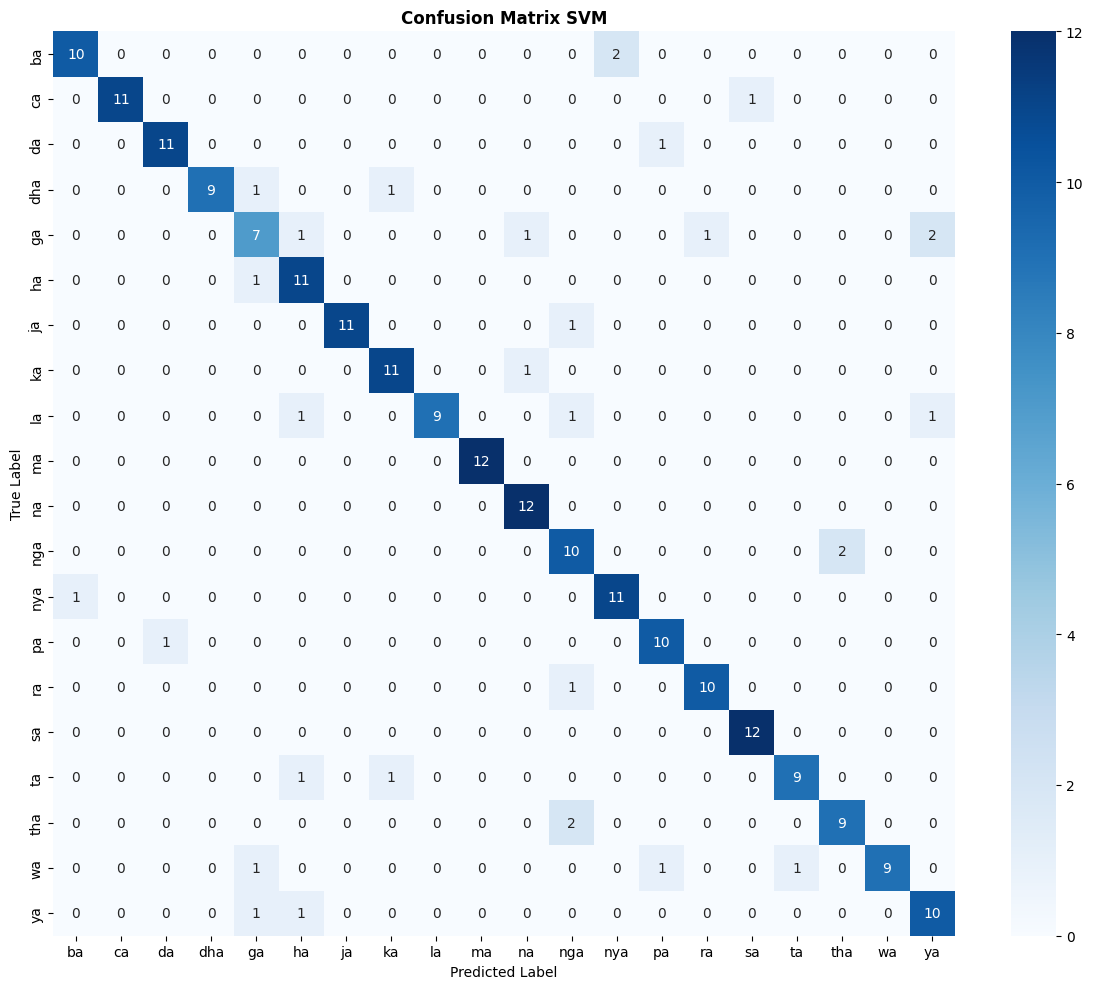

In [32]:
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix SVM', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()